In [1]:
!pip install requests joblib -q

In [2]:
import numpy as np
import pandas as pd
import requests
import tensorflow as tf
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import GRU,Dense,Dropout

from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau

In [3]:
print(tf.__version__)

gpus=tf.config.list_physical_devices("GPU")

for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu,True)

tf.config.optimizer.set_jit(True)

print(tf.config.list_physical_devices("GPU"))

2.20.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
API_KEY="76e79bea0310025bde0ea382ae51ecb7cc4d561f"

TICKER="AAPL"

START="2020-01-01"

END="2026-05-27"

url=f"https://api.tiingo.com/tiingo/daily/{TICKER}/prices"

params={
"startDate":START,
"endDate":END,
"token":API_KEY
}

data=requests.get(url,params=params).json()

df=pd.DataFrame(data)

df["date"]=pd.to_datetime(df["date"])

df.set_index("date",inplace=True)

display(df.head())

,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
date,,,,,,,,,,,,
2020-01-02 00:00:00+00:00,300.35,300.60,295.19,296.24,33911864,72.339604,72.399817,71.096813,71.349706,135647456,0.0,1.0
2020-01-03 00:00:00+00:00,297.43,300.58,296.50,297.15,36633878,71.636319,72.395000,71.412328,71.568881,146535512,0.0,1.0
2020-01-06 00:00:00+00:00,299.80,299.96,292.75,293.79,29644644,72.207136,72.245672,70.509136,70.759621,118578576,0.0,1.0
2020-01-07 00:00:00+00:00,298.39,300.90,297.48,299.84,27877655,71.867536,72.472072,71.648362,72.216770,111510620,0.0,1.0
2020-01-08 00:00:00+00:00,303.19,304.44,297.16,297.16,33090946,73.023621,73.324685,71.571289,71.571289,132363784,0.0,1.0


In [5]:
df["EMA_10"]=df["close"].ewm(span=10).mean()

df["EMA_30"]=df["close"].ewm(span=30).mean()


delta=df["close"].diff()

gain=delta.clip(lower=0)

loss=-delta.clip(upper=0)

avg_gain=gain.rolling(14).mean()

avg_loss=loss.rolling(14).mean()

rs=avg_gain/avg_loss

df["RSI"]=100-(100/(1+rs))


df=df.dropna()

display(df.head())

,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor,EMA_10,EMA_30,RSI
date,,,,,,,,,,,,,,,
2020-01-23 00:00:00+00:00,319.23,319.56,315.65,317.92,26117993,76.886871,76.966352,76.024625,76.571356,104471972,0.0,1.0,314.867092,311.808752,71.902552
2020-01-24 00:00:00+00:00,318.31,323.33,317.52,320.25,36634380,76.665288,77.874361,76.475016,77.132539,146537520,0.0,1.0,315.519380,312.448153,75.401460
2020-01-27 00:00:00+00:00,308.95,311.77,304.88,310.06,40485005,74.410923,75.090123,73.430659,74.678267,161940020,0.0,1.0,314.284192,312.115367,59.513412
2020-01-28 00:00:00+00:00,317.69,318.40,312.19,312.60,40558486,76.515961,76.686965,75.191280,75.290029,162233944,0.0,1.0,314.920611,312.629938,67.412486
2020-01-29 00:00:00+00:00,324.34,327.85,321.38,324.45,54149928,78.117620,78.963007,77.404701,78.144114,216599712,0.0,1.0,316.671909,313.681618,68.465165


In [6]:
features=df[[
"open",
"high",
"low",
"close",
"volume",
"EMA_10",
"EMA_30",
"RSI"
]]

scaler=MinMaxScaler()

scaled=scaler.fit_transform(features)

scaled.shape

(1594, 8)

In [7]:
split=int(len(scaled)*0.80)

train=scaled[:split]

test=scaled[split:]

print(train.shape)

print(test.shape)

(1275, 8)
(319, 8)


In [8]:
WINDOW=100

FORECAST=3


def create_dataset(data):

    X=[]

    y=[]

    for i in range(len(data)-WINDOW-FORECAST):

        X.append(
            data[
                i:i+WINDOW
            ]
        )

        y.append(
            data[
                i+WINDOW:i+WINDOW+FORECAST,
                3
            ]
        )

    return np.array(X),np.array(y)


X_train,y_train=create_dataset(train)

X_test,y_test=create_dataset(test)

print(X_train.shape)

print(y_train.shape)

print(X_test.shape)

print(y_test.shape)

(1172, 100, 8)
(1172, 3)
(216, 100, 8)
(216, 3)


In [9]:
BATCH=64

train_ds=tf.data.Dataset.from_tensor_slices((X_train,y_train)).shuffle(1000).batch(BATCH).prefetch(tf.data.AUTOTUNE)

test_ds=tf.data.Dataset.from_tensor_slices((X_test,y_test)).batch(BATCH).prefetch(tf.data.AUTOTUNE)

In [10]:
model=Sequential()

model.add(
GRU(
128,
return_sequences=True,
input_shape=(WINDOW,8)
)
)

model.add(
Dropout(0.05)
)

model.add(
GRU(
64
)
)

model.add(
Dense(
64,
activation="relu"
)
)

model.add(
Dense(
FORECAST
)
)

model.compile(
optimizer="adam",
loss="mse"
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 100, 128)       │        52,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,595 (369.51 KB)

 Trainable params: 94,595 (369.51 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
callbacks=[

EarlyStopping(
patience=15,
restore_best_weights=True
),

ReduceLROnPlateau(
factor=0.5,
patience=5
)

]

history=model.fit(

train_ds,

validation_data=test_ds,

epochs=100,

callbacks=callbacks

)

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - loss: 0.0183 - val_loss: 0.0034 - learning_rate: 0.0010
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.0033 - val_loss: 0.0075 - learning_rate: 0.0010
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0034 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0024 - val_loss: 0.0010 - learning_rate: 0.0010
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0021 - val_loss: 3.7119e-04 - learning_rate: 0.0010
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0022 - val_loss: 3.7278e-04 - learning_rate: 0.0010
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0020 - val_loss: 4.2388e-04 - learning_rate: 0.0010
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0020 - val_loss: 8.2953e-04 - learning_rate: 0.0010
Epoch 9/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0021 - val_loss: 0.0013 - learning_rate: 

In [12]:
last=scaled[-WINDOW:]

last=last.reshape(1,WINDOW,8)

forecast=model.predict(last)[0]

forecast

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 671ms/step


array([0.5120321 , 0.50858647, 0.505066  ], dtype=float32)

In [13]:
temp=np.zeros((FORECAST,8))

temp[:,3]=forecast

forecast=scaler.inverse_transform(temp)[:,3]

forecast

array([311.26881258, 309.89314668, 308.48759155])

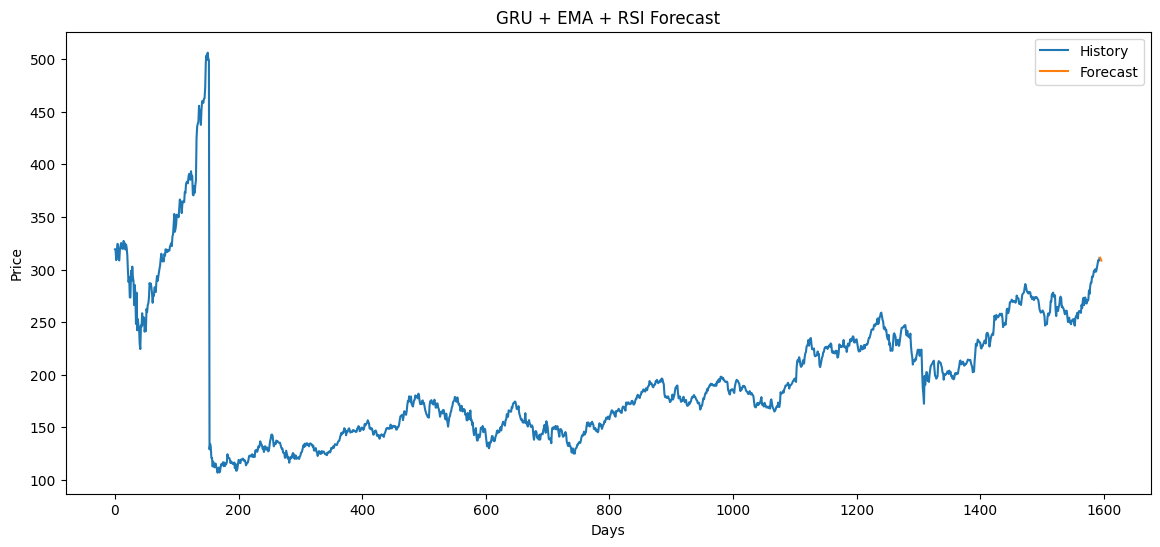

In [14]:
close=scaler.inverse_transform(scaled)[:,3]

plt.figure(figsize=(14,6))

plt.plot(close,label="History")

future=np.arange(len(close),len(close)+FORECAST)

plt.plot(future,forecast,label="Forecast")

plt.title("GRU + EMA + RSI Forecast")

plt.xlabel("Days")

plt.ylabel("Price")

plt.legend()

plt.show()

In [15]:
train_pred=model.predict(X_train)

train_pred=train_pred[:,0]

train_actual=y_train[:,0]


temp_pred=np.zeros((len(train_pred),8))

temp_actual=np.zeros((len(train_actual),8))


temp_pred[:,3]=train_pred

temp_actual[:,3]=train_actual


train_pred=scaler.inverse_transform(temp_pred)[:,3]

train_actual=scaler.inverse_transform(temp_actual)[:,3]

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


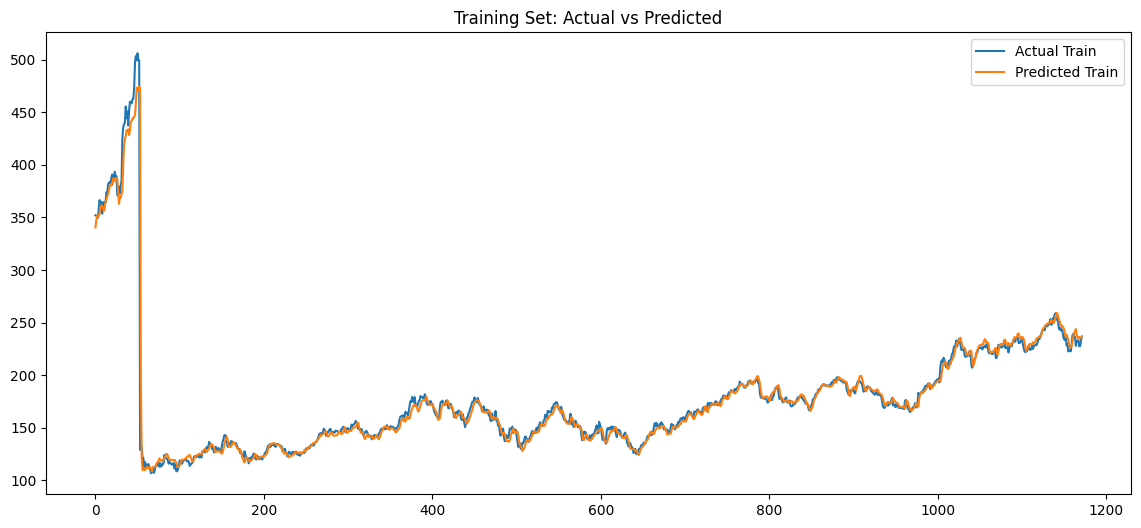

In [16]:
plt.figure(figsize=(14,6))

plt.plot(train_actual,label="Actual Train")

plt.plot(train_pred,label="Predicted Train")

plt.title("Training Set: Actual vs Predicted")

plt.legend()

plt.show()

In [17]:
test_pred=model.predict(X_test)

test_pred=test_pred[:,0]

test_actual=y_test[:,0]


temp_pred=np.zeros((len(test_pred),8))

temp_actual=np.zeros((len(test_actual),8))


temp_pred[:,3]=test_pred

temp_actual[:,3]=test_actual


test_pred=scaler.inverse_transform(temp_pred)[:,3]

test_actual=scaler.inverse_transform(temp_actual)[:,3]

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


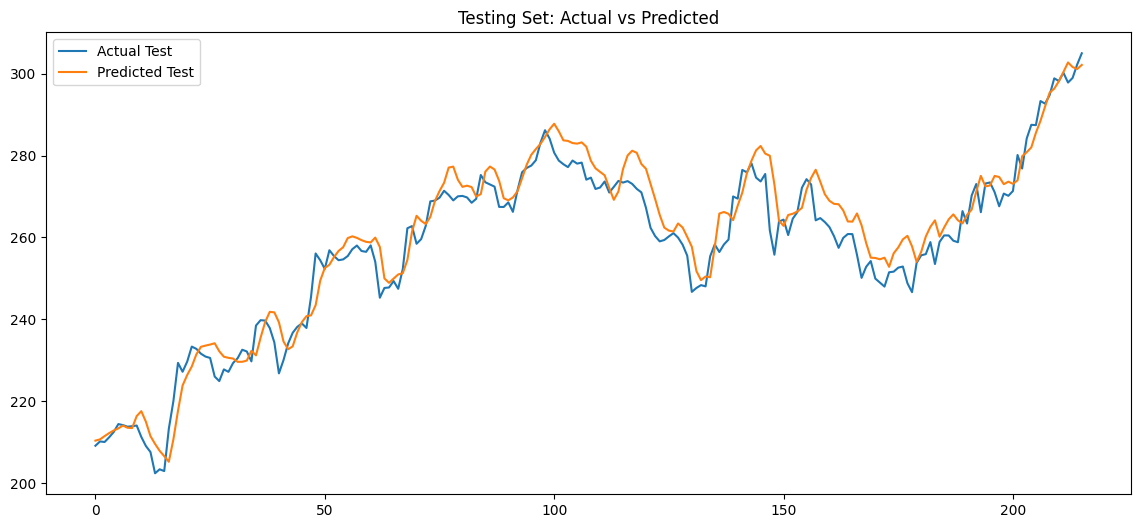

In [18]:
plt.figure(figsize=(14,6))

plt.plot(test_actual,label="Actual Test")

plt.plot(test_pred,label="Predicted Test")

plt.title("Testing Set: Actual vs Predicted")

plt.legend()

plt.show()

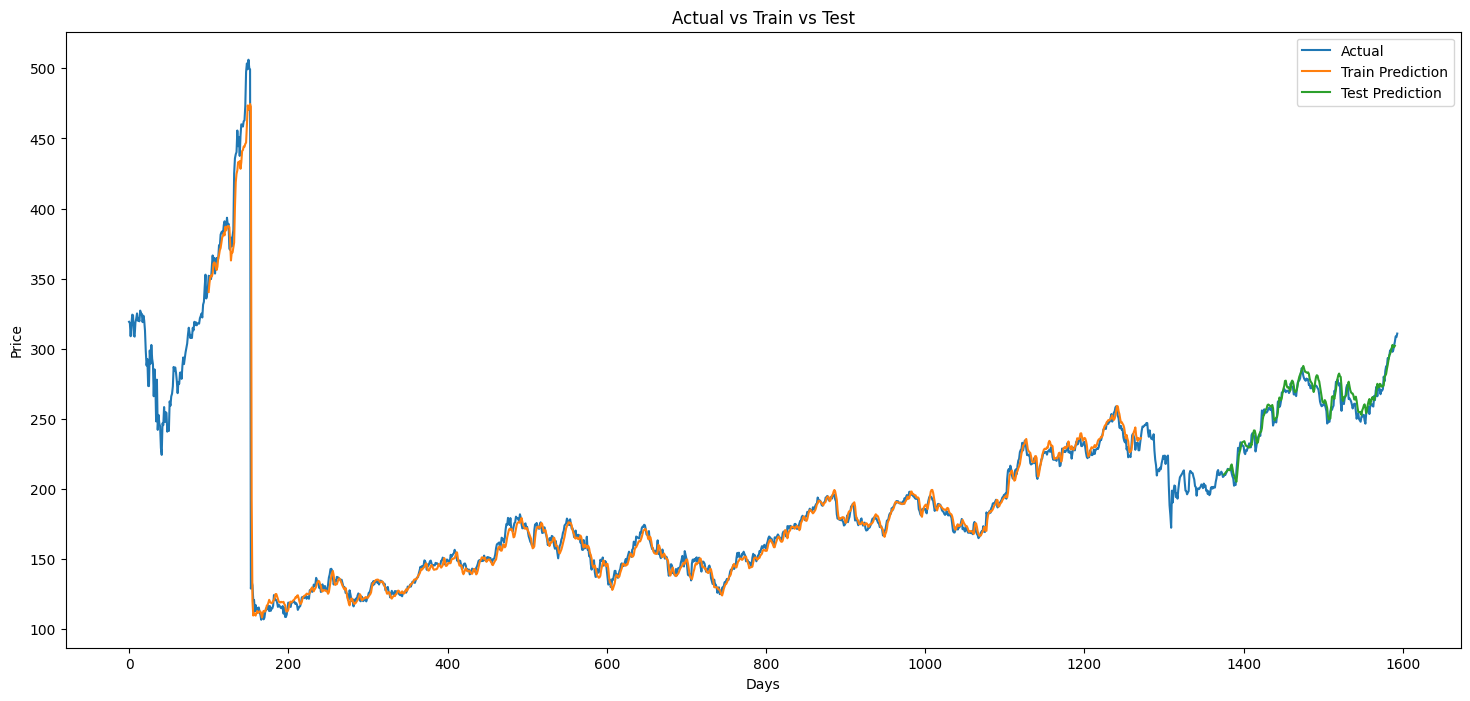

In [19]:
close=scaler.inverse_transform(scaled)[:,3]


train_plot=np.empty(len(close))

train_plot[:]=np.nan


test_plot=np.empty(len(close))

test_plot[:]=np.nan


train_start=WINDOW

train_end=train_start+len(train_pred)

train_plot[train_start:train_end]=train_pred


test_start=split+WINDOW

test_end=test_start+len(test_pred)

test_plot[test_start:test_end]=test_pred


plt.figure(figsize=(18,8))

plt.plot(close,label="Actual")

plt.plot(train_plot,label="Train Prediction")

plt.plot(test_plot,label="Test Prediction")

plt.title("Actual vs Train vs Test")

plt.xlabel("Days")

plt.ylabel("Price")

plt.legend()

plt.show()